In [41]:
import pandas as pd
df = pd.read_csv(
    r"C:\Users\Karnaveer Singh\Desktop\DecodingML\spamhamdata.csv",
    sep='\t', header=None, names=['label', 'text']
)

## csv usually seperates by commas , here we have to seperate by tab

In [42]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [43]:
import re
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Karnaveer
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [44]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [45]:
corpus = []

for i in range(0, len(df)):
    #Remove everything except letters (punctuation, numbers → spaces)
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    
  
    review = review.lower()
    
    review = review.split()
    
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    
    review = ' '.join(review)
    
    # Step 6: Add to corpus
    corpus.append(review)


In [46]:
#corpus

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)


# === CountVectorizer Parameters Explained ===

# input: 'content' (default) | 'filename' | 'one_value' 
# How to read text - default reads text directly

# lowercase: True (default) | False
# Convert all text to lowercase first? Yes by default

# stop_words: None | 'english' | list of words
# Words to ignore: stopwords.words('english') or your own list
# vectorizer = CountVectorizer(stop_words='english')

# max_features: None (default) | int (e.g. 1000)
# Max number of words to keep (most frequent only)
# vectorizer = CountVectorizer(max_features=5000)

# min_df: 1 (default) | int | float (0.0-1.0)
# Ignore words appearing in < min_df documents
# min_df=2 = ignore words in 1 doc only
# min_df=0.05 = ignore words in <5% of docs

# max_df: 1.0 (default) | int | float (0.0-1.0) 
# Ignore words appearing in > max_df documents
# max_df=0.95 = ignore words in 95%+ of docs

# binary: False (default) | True
# Count occurrences? (False) or just 0/1 presence? (True)
# vectorizer = CountVectorizer(binary=True)

# ngram_range: (1,1) (default) | (1,2) | (2,2)
# Single words (1,1), bigrams (1,2), or trigrams (1,3)
# vectorizer = CountVectorizer(ngram_range=(1,2))  # words + 2-word phrases

# max_df_combine: 'dense' | 'sparse' (internal, rarely used)

# analyzer: 'word' (default) | 'char' | 'char_wb'
# Split by words, characters, or word-boundary chars

# Example with common settings:
# vectorizer = CountVectorizer(stop_words='english', max_features=5000, 
#                              min_df=2, max_df=0.95, ngram_range=(1,2))

In [48]:
vectorizer.get_feature_names_out()

array(['aa', 'aah', 'aaniy', 'aaooooright', 'aathi', 'ab', 'abbey', 'abdomen', 'abeg', 'abel', 'aberdeen', 'abi', 'abil', 'abiola', 'abj', 'abl', 'abnorm', 'abouta', 'abroad', 'absenc', 'absolut', 'absolutli', 'abstract', 'abt', 'abta', 'aburo', 'abus', 'ac', 'academ', 'acc', ..., 'yovil', 'yowif', 'yoyyooo', 'yr', 'ystrday', 'yt', 'ything', 'yummi', 'yummmm', 'yun', 'yunni', 'yuo', 'yuou', 'yup', 'yupz', 'zac', 'zaher', 'zealand', 'zebra', 'zed', 'zero', 'zf', 'zhong', 'zindgi', 'zoe', 'zogtoriu', 'zoom', 'zouk', 'zs', 'zyada'], shape=(6296,), dtype=object)

In [49]:

import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000, 
    formatter=dict(float=lambda x: "%.3g" % x))

X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 45127 stored elements and shape (5572, 6296)>

In [50]:
vectorizer.vocabulary_

{'go': 2171,
 'jurong': 2827,
 'point': 4091,
 'crazi': 1169,
 'avail': 379,
 'bugi': 738,
 'great': 2245,
 'world': 6135,
 'la': 2932,
 'buffet': 736,
 'cine': 964,
 'got': 2208,
 'amor': 190,
 'wat': 5957,
 'ok': 3760,
 'lar': 2960,
 'joke': 2794,
 'wif': 6056,
 'oni': 3785,
 'free': 2007,
 'entri': 1673,
 'wkli': 6101,
 'comp': 1058,
 'win': 6067,
 'fa': 1791,
 'cup': 1220,
 'final': 1890,
 'tkt': 5536,
 'st': 5103,
 'may': 3276,
 'text': 5420,
 'receiv': 4402,
 'question': 4319,
 'std': 5131,
 'txt': 5695,
 'rate': 4364,
 'appli': 262,
 'dun': 1551,
 'say': 4651,
 'earli': 1568,
 'hor': 2477,
 'alreadi': 163,
 'nah': 3532,
 'think': 5468,
 'goe': 2175,
 'usf': 5811,
 'live': 3070,
 'around': 302,
 'though': 5485,
 'freemsg': 2013,
 'hey': 2408,
 'darl': 1267,
 'week': 5992,
 'word': 6129,
 'back': 414,
 'like': 3042,
 'fun': 2059,
 'still': 5152,
 'tb': 5367,
 'xxx': 6202,
 'chg': 922,
 'send': 4721,
 'rcv': 4375,
 'even': 1722,
 'brother': 710,
 'speak': 5037,
 'treat': 5638,
 'ai

In [51]:
from sklearn.feature_extraction.text import CountVectorizer
## for Binary BOW enable binary=True
cv=CountVectorizer(max_features=100,binary=True,ngram_range=(2,3))
## also include phrases of 2 and 3 words together
X=cv.fit_transform(corpus).toarray()

In [52]:
cv.vocabulary_


{'free entri': np.int64(32),
 'claim call': np.int64(17),
 'call claim': np.int64(3),
 'free call': np.int64(31),
 'chanc win': np.int64(16),
 'txt word': np.int64(91),
 'let know': np.int64(53),
 'go home': np.int64(35),
 'pleas call': np.int64(69),
 'lt gt': np.int64(59),
 'want go': np.int64(97),
 'like lt': np.int64(54),
 'like lt gt': np.int64(55),
 'sorri call': np.int64(82),
 'call later': np.int64(11),
 'sorri call later': np.int64(83),
 'ur award': np.int64(92),
 'call custom': np.int64(4),
 'custom servic': np.int64(24),
 'cash prize': np.int64(15),
 'call custom servic': np.int64(5),
 'po box': np.int64(70),
 'tri contact': np.int64(88),
 'draw show': np.int64(28),
 'show prize': np.int64(80),
 'prize guarante': np.int64(74),
 'guarante call': np.int64(41),
 'valid hr': np.int64(95),
 'draw show prize': np.int64(29),
 'show prize guarante': np.int64(81),
 'prize guarante call': np.int64(75),
 'select receiv': np.int64(77),
 'privat account': np.int64(71),
 'account statement

### TF -IDF implementation 
#### Scores words by: (how often word appears in doc) × (how rare word is across all docs)
##### common words like "the" get low scores; unique words get high scores
- Search engines (rank relevant docs)
- Text classification (spam detection, sentiment)
- Document clustering
- Keyword extraction
- Recommendation systems


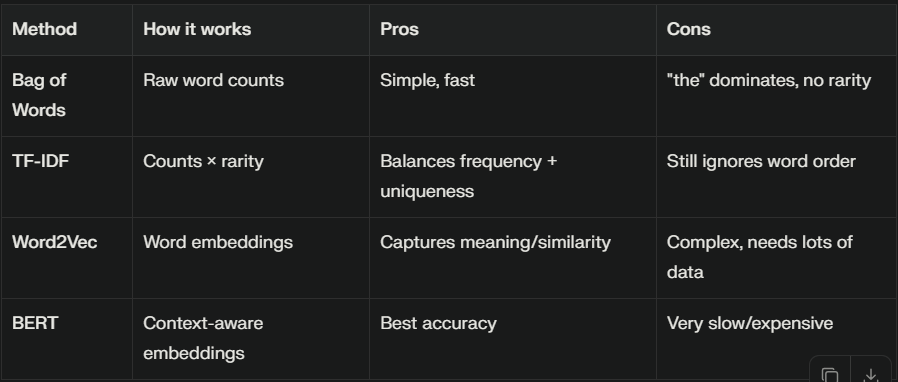


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(stop_words=[stopwords],max_features=100,)
X = tf.fit_transform(corpus).toarray()

# fit() alone: Learns vocabulary + IDF weights from corpus, but returns nothing useful (just fits the transformer)

# transform() alone: Converts text → numbers using PREVIOUSLY learned vocab (needs fit() first)

# fit_transform(): Does both steps at once = learn vocab AND convert your training data

In [54]:
tf.vocabulary_

{'go': np.int64(22),
 'great': np.int64(25),
 'got': np.int64(24),
 'wat': np.int64(91),
 'ok': np.int64(57),
 'free': np.int64(18),
 'win': np.int64(95),
 'text': np.int64(77),
 'txt': np.int64(86),
 'say': np.int64(68),
 'alreadi': np.int64(0),
 'think': np.int64(80),
 'hey': np.int64(28),
 'week': np.int64(93),
 'back': np.int64(4),
 'like': np.int64(39),
 'still': np.int64(73),
 'send': np.int64(70),
 'even': np.int64(15),
 'friend': np.int64(19),
 'prize': np.int64(63),
 'claim': np.int64(8),
 'call': np.int64(5),
 'mobil': np.int64(48),
 'co': np.int64(9),
 'home': np.int64(30),
 'want': np.int64(90),
 'today': np.int64(82),
 'cash': np.int64(7),
 'day': np.int64(12),
 'repli': np.int64(65),
 'www': np.int64(97),
 'right': np.int64(66),
 'thank': np.int64(78),
 'take': np.int64(75),
 'time': np.int64(81),
 'messag': np.int64(45),
 'oh': np.int64(56),
 'ye': np.int64(98),
 'make': np.int64(43),
 'way': np.int64(92),
 'feel': np.int64(16),
 'dont': np.int64(14),
 'miss': np.int64(4

In [55]:
print(X[0])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0.401 0 0.471 0.555 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0.555 0 0 0 0 0 0 0 0]


In [ ]:
## There is ngram in tf - idf as well 